In [1]:
import mlflow
import numpy as np
import pylab as plt
import pandas as pd

In [2]:
!rsync -avz cluster.ies:/mnt/work/dhuseljic/mlflow/perf_dal /home/dhuseljic/mlflow

receiving incremental file list
perf_dal/diverse_batches/
perf_dal/diverse_batches/291493541886119652/
perf_dal/diverse_batches/291493541886119652/meta.yaml
perf_dal/diverse_batches/291493541886119652/125a99ec69224722b839c480416b4529/
perf_dal/diverse_batches/291493541886119652/125a99ec69224722b839c480416b4529/meta.yaml
perf_dal/diverse_batches/291493541886119652/125a99ec69224722b839c480416b4529/artifacts/
perf_dal/diverse_batches/291493541886119652/125a99ec69224722b839c480416b4529/metrics/
perf_dal/diverse_batches/291493541886119652/125a99ec69224722b839c480416b4529/metrics/ACE
perf_dal/diverse_batches/291493541886119652/125a99ec69224722b839c480416b4529/metrics/BS
perf_dal/diverse_batches/291493541886119652/125a99ec69224722b839c480416b4529/metrics/ECE
perf_dal/diverse_batches/291493541886119652/125a99ec69224722b839c480416b4529/metrics/NLL
perf_dal/diverse_batches/291493541886119652/125a99ec69224722b839c480416b4529/metrics/accuracy
perf_dal/diverse_batches/291493541886119652/125a99ec692

In [3]:
# client = mlflow.tracking.MlflowClient(tracking_uri=f'sqlite:///decision_flips.db')
# experiment_id = client.get_experiment_by_name('decision_flips').experiment_id
client = mlflow.tracking.MlflowClient(tracking_uri=f'file:////home/dhuseljic/mlflow/perf_dal/diverse_batches/')
experiment_id = client.get_experiment_by_name('diverse_batches_v7').experiment_id
query_list = [
    "parameter.dataset_name= 'cifar10'",
]
runs = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
print('Found {} experiments'.format(len(runs)))

Found 40 experiments


In [4]:
from collections import defaultdict
acc_curves = defaultdict(list)

for run in runs:
    al_strat = run.data.params['al.strategy']
    acc_curves[al_strat].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

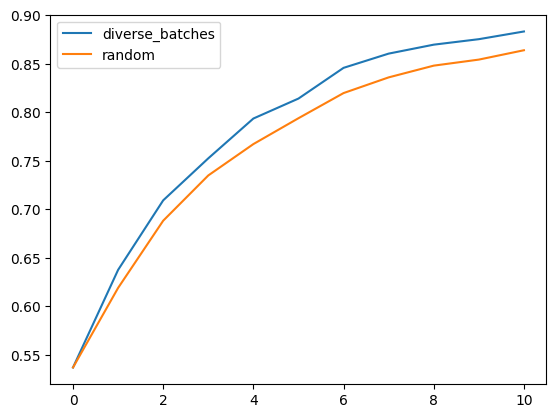

In [5]:
for key in acc_curves:
    plt.plot(np.mean(acc_curves[key], axis=0), label=key)
plt.legend()